In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML models
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Metrics
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

In [2]:
df = pd.read_csv("Libraries_-_2017_Wi_Fi_Usage.csv")

# Preview
df.head()

,MONTH,NUMBER OF SESSIONS,YTD
0,January,309343.0,"309,343"
1,February,289538.0,"598,881"
2,March,324300.0,"923,181"
3,April,307825.0,"1,231,006"
4,May,309472.0,"1,540,478"


In [3]:
df.info()
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MONTH               12 non-null     str    
 1   NUMBER OF SESSIONS  9 non-null      float64
 2   YTD                 9 non-null      str    
dtypes: float64(1), str(2)
memory usage: 571.0 bytes


MONTH                 0
NUMBER OF SESSIONS    3
YTD                   3
dtype: int64

In [4]:
# Fill missing numeric values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Drop duplicates
df.drop_duplicates(inplace=True)

In [6]:
target = "Total_WiFi_Sessions"

df.columns = df.columns.str.strip()

if target in df.columns:
    X = df.drop(columns=[target])
    y = df[target]
else:
    print(f"Column '{target}' not found. Available columns:")
    print(df.columns.tolist())

Column 'Total_WiFi_Sessions' not found. Available columns:
['MONTH', 'NUMBER OF SESSIONS', 'YTD']


In [9]:
print(df.head())
print(df.columns)

      MONTH  NUMBER OF SESSIONS        YTD
0   January            309343.0    309,343
1  February            289538.0    598,881
2     March            324300.0    923,181
3     April            307825.0  1,231,006
4       May            309472.0  1,540,478
Index(['MONTH', 'NUMBER OF SESSIONS', 'YTD'], dtype='str')


In [12]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Step 1: Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 2: Train model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Step 3: Predict
y_pred_rf = rf_model.predict(X_test)

# Step 4: Evaluate
print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest R2: 0.7737541961457275
Random Forest RMSE: 0.5444947498920153


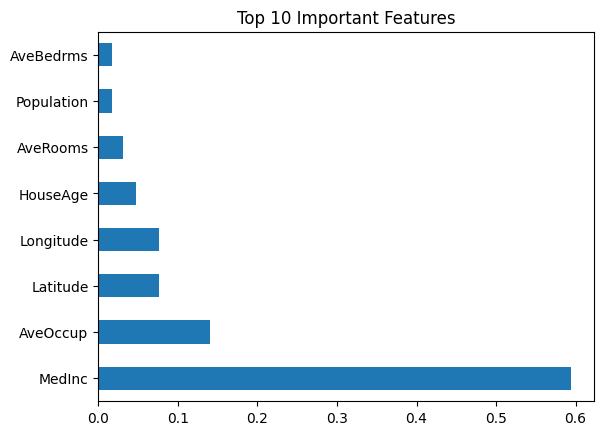

In [16]:
importances = rf_model.feature_importances_
features = X.columns

feat_importance = pd.Series(importances, index=features)
feat_importance.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()